# Reglas de asociación: canastas

Se preparan las transacciones para minería de itemsets frecuentes. Cada proceso (`ocid`) de
`data/final/` es una transacción; los ítems son la columna `canasta` (ya construida en
`01_EDA_KDD/KDD/a_transformaciones.ipynb`, `construir_canasta`). No se filtra por `postor_unico`
(ver §3) — se preparan dos conjuntos: completo (FP-Growth) y un subconjunto Q1 2025 (Apriori).

### Imports

In [1]:
import os, socket
from pathlib import Path

import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, functions as F

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})

### Utilidades

- Constantes

In [2]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent     # el notebook vive en 04_Asociacion/, el repo está un nivel arriba
final_dir = proyecto / "data" / "final"
out_dir = proyecto / "04_Asociacion" / "temp" / "a_canastas"
out_dir.mkdir(parents=True, exist_ok=True)

- Spark

In [3]:
spark_master = os.environ.get("spark_master", "local[*]")

builder = (SparkSession.builder
           .appName("asociacion-canastas")
           .master(spark_master)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "2g"))
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "2g"))
           .config("spark.sql.shuffle.partitions", "24")
           .config("spark.ui.showConsoleProgress", "false")
           .config("spark.sql.session.timeZone", "America/Lima"))

if spark_master.startswith("spark://"):
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

### Verificación del cluster

In [4]:
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()

print(f"Master        : {sc.master}")
print(f"Executors     : {estado.size() - 1}")
print(f"Cores totales : {sc.defaultParallelism}")
print(f"Memoria driver: {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job    : http://localhost:4040")

Master        : spark://spark-master:7077
Executors     : 0
Cores totales : 2
Memoria driver: 2.0 GB
UI del job    : http://localhost:4040


---
### 1. Carga de `data/final`

In [5]:
assert final_dir.exists(), f"No se encuentra {final_dir}; corre 01_EDA_KDD/KDD/a_transformaciones.ipynb"

procesos = spark.read.parquet(str(final_dir)).select(
    "ocid", "anio", "mes", "entidad", "region", "metodo_detalle",
    "categoria", "tramo_monto", "rubro", "canasta", "postor_unico",
).cache()

N = procesos.count()
print(f"Dataset cargado: {N:,} filas")

Dataset cargado: 231,165 filas


---
### 2. Criterio de transacción

- Cada proceso (`ocid`) = una transacción.
- Ítems = `canasta` (`KDD/a_transformaciones.ipynb` §3a, `construir_canasta`): `cat=`, `met=`,
  `reg=`, `monto=`, `rubro=` (multivalor), `comp=postor_unico`/`comp=varios_postores`.
- No se reconstruye la canasta aquí, solo se reutiliza.

**Por qué no se filtra por `postor_unico=1`:** si se filtrara primero, `comp=postor_unico` quedaría
presente en el 100% de las transacciones minadas, y cualquier regla `{X} → {comp=postor_unico}`
tendría confianza=lift=1 siempre — trivial, no informativo (ya se garantizó esa conclusión al
filtrar). Se usan las canastas completas para que ese ítem varíe de verdad y las reglas hacia él
sean reales.

---
### 3. Estadísticas reales de `canasta`

In [6]:
tam = procesos.select(F.size("canasta").alias("tam"))
tam.selectExpr(
    "min(tam) as minimo",
    "percentile_approx(tam, 0.5) as mediana",
    "max(tam) as maximo",
).show()

+------+-------+------+
|minimo|mediana|maximo|
+------+-------+------+
|     4|      6|    17|
+------+-------+------+



/opt/conda/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.9.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/conda/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


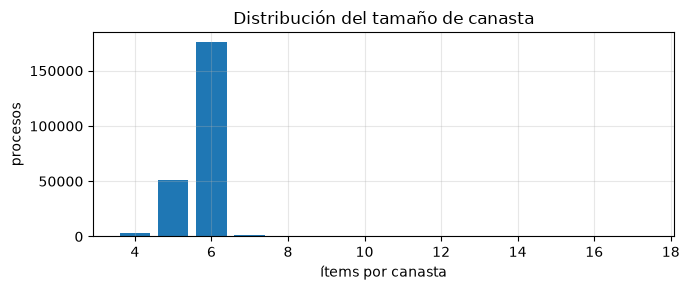

In [7]:
tam_pd = tam.groupBy("tam").count().orderBy("tam").toPandas()
plt.figure(figsize=(7, 3))
plt.bar(tam_pd["tam"], tam_pd["count"])
plt.xlabel("ítems por canasta"); plt.ylabel("procesos"); plt.title("Distribución del tamaño de canasta")
plt.tight_layout(); plt.show()

In [8]:
items = (procesos.select(F.explode("canasta").alias("item"))
         .groupBy("item")
         .count()
         .withColumnRenamed("count", "soporte_abs")
         .withColumn("soporte_pct", F.round(100 * F.col("soporte_abs") / N, 1))
         .orderBy(F.desc("soporte_abs")))

n_items_distintos = items.count()
print(f"Ítems distintos: {n_items_distintos}")
items.show(15, truncate=False)

Ítems distintos: 304


+--------------------------------+-----------+-----------+
|item                            |soporte_abs|soporte_pct|
+--------------------------------+-----------+-----------+
|comp=varios_postores            |187077     |80.9       |
|cat=GOODS                       |104001     |45.0       |
|met=ADJUDICACIÓN SIMPLIFICADA   |102896     |44.5       |
|monto=2_50k-200k                |102853     |44.5       |
|cat=SERVICES                    |100046     |43.3       |
|monto=3_200k-1M                 |69505      |30.1       |
|reg=LIMA                        |64117      |27.7       |
|rubro=72                        |54469      |23.6       |
|rubro=81                        |27160      |11.7       |
|cat=WORKS                       |27118      |11.7       |
|met=SUBASTA INVERSA ELECTRÓNICA |27041      |11.7       |
|monto=4_1M-5M                   |23806      |10.3       |
|comp=postor_unico               |23136      |10.0       |
|met=LICITACIÓN PÚBLICA ABREVIADA|15694      |6.8       

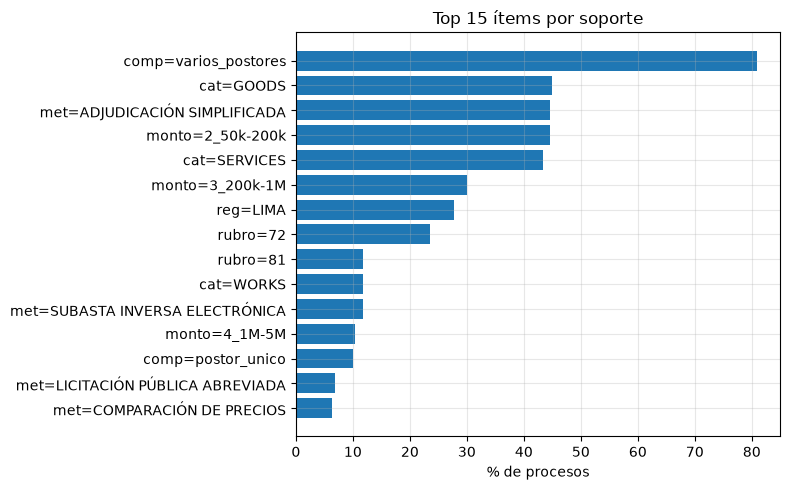

In [9]:
top_items = items.limit(15).toPandas().iloc[::-1]
plt.figure(figsize=(8, 5))
plt.barh(top_items["item"], top_items["soporte_pct"])
plt.xlabel("% de procesos"); plt.title("Top 15 ítems por soporte")
plt.tight_layout(); plt.show()

**Lectura.** 304 ítems distintos, canasta de 4-17 ítems (mediana 6). El soporte varía mucho:
`comp=varios_postores` domina (80.9%, esperado — la mayoría de procesos sí tiene competencia),
`cat=GOODS`/`met=ADJUDICACIÓN SIMPLIFICADA`/`monto=2_50k-200k` rondan 44-45%, y `comp=postor_unico`
(el ítem de interés para P1) tiene 10.0% de soporte — ni tan raro que quede fuera de cualquier
umbral razonable, ni tan común que sea trivial. Esto confirma que no filtrar fue la decisión
correcta: con 80.9% vs 10.0%, `comp=` sí varía y las reglas hacia `postor_unico` van a ser reales.

---
### 4. Subconjunto para Apriori: Q1 2025

Apriori (`mlxtend`, sin Spark) no escala tan bien como FP-Growth — se usa un subconjunto real y
justificable (el trimestre más reciente), no una muestra arbitraria.

In [10]:
q1_2025 = procesos.where("anio = 2025 AND mes <= 3")
n_q1 = q1_2025.count()
print(f"Q1 2025 (meses 1-3): {n_q1:,} filas de {N:,} totales ({100*n_q1/N:.1f}%)")

Q1 2025 (meses 1-3): 14,263 filas de 231,165 totales (6.2%)


---
### 5. Escritura a `temp/a_canastas/`

In [11]:
procesos.select("ocid", "canasta").write.mode("overwrite").parquet(str(out_dir / "full"))
q1_2025.select("ocid", "canasta").write.mode("overwrite").parquet(str(out_dir / "q1_2025"))
items.write.mode("overwrite").parquet(str(out_dir / "support_full"))

print("Escrito en temp/a_canastas/: full, q1_2025, support_full")

Escrito en temp/a_canastas/: full, q1_2025, support_full


#### Verificación (round-trip)

In [12]:
chk_full = spark.read.parquet(str(out_dir / "full")).count()
chk_q1 = spark.read.parquet(str(out_dir / "q1_2025")).count()
chk_items = spark.read.parquet(str(out_dir / "support_full")).count()

assert chk_full == N, f"full: esperaba {N}, leí {chk_full}"
assert chk_q1 == n_q1, f"q1_2025: esperaba {n_q1}, leí {chk_q1}"
assert chk_items == n_items_distintos, f"support_full: esperaba {n_items_distintos}, leí {chk_items}"
print(f"OK: full={chk_full:,} | q1_2025={chk_q1:,} | support_full={chk_items}")

OK: full=231,165 | q1_2025=14,263 | support_full=304


---
### 6. Cerrar sesión de Spark

In [13]:
spark.stop()